In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!git clone https://github.com/shubhamkovhal01/Cardiac-Segmentation.git
%cd Cardiac-Segmentation
!git config pull.rebase false
!git config user.email "shubhamkovhal@gmail.com"
!git config user.name "Shubhamkovhal01"

Cloning into 'Cardiac-Segmentation'...
remote: Enumerating objects: 42, done.
remote: Counting objects: 100% (5/5), done.
remote: Compressing objects: 100% (5/5), done.
remote: Total 42 (delta 0), reused 2 (delta 0), pack-reused 37 (from 1)
Receiving objects: 100% (42/42), 68.03 MiB | 42.22 MiB/s, done.
Resolving deltas: 100% (12/12), done.
/content/Cardiac-Segmentation


In [3]:
!pip install monai nibabel matplotlib numpy -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 58.6 MB/s eta 0:00:00


In [4]:
from monai.apps import DecathlonDataset

<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.


In [5]:
from pathlib import Path

# Phase 1 : Exploration

In [6]:
root_dir=Path("/content/drive/MyDrive/Cardiac-Segmentation/data")
root_dir.mkdir(parents=True,exist_ok=True)

In [7]:
dataset=DecathlonDataset(
    root_dir=root_dir,
    task="Task02_Heart",
    section="training",
    download=True
)



2026-06-21 22:13:16,416 - INFO - Verified 'Task02_Heart.tar', md5: 06ee59366e1e5124267b774dbd654057.
2026-06-21 22:13:16,417 - INFO - File exists: /content/drive/MyDrive/Cardiac-Segmentation/data/Task02_Heart.tar, skipped downloading.
2026-06-21 22:13:16,711 - INFO - Non-empty folder exists in /content/drive/MyDrive/Cardiac-Segmentation/data/Task02_Heart, skipped extracting.


Loading dataset: 100%|██████████| 16/16 [00:32<00:00,  2.04s/it]


In [8]:
import os
images=os.listdir("/content/drive/MyDrive/Cardiac-Segmentation/data/Task02_Heart/imagesTr")
labels=os.listdir("/content/drive/MyDrive/Cardiac-Segmentation/data/Task02_Heart/labelsTr")
print(f"Number of images: {len(images)}")
print(f"Number of labels: {len(labels)}")

Number of images: 21
Number of labels: 22


In [9]:
images=[image for image in images if not image.startswith(".") and not image.startswith("_")]
labels=[label for label in labels if not label.startswith(".") and not label.startswith("_")]

In [10]:
print(f"Number of images: {len(images)}")
print(f"Number of labels: {len(labels)}")

Number of images: 20
Number of labels: 20


In [11]:
image_set=set(images)
label_set=set(labels)
print(f"Perfectly paired: {image_set == label_set}")
print(f"Images missing labels: {image_set - label_set}")
print(f"Labels missing images: {label_set - image_set}")

Perfectly paired: True
Images missing labels: set()
Labels missing images: set()


In [12]:
import nibabel as nib
import numpy as np

img_path="/content/drive/MyDrive/Cardiac-Segmentation/data/Task02_Heart/imagesTr/"+images[0]
label_path="/content/drive/MyDrive/Cardiac-Segmentation/data/Task02_Heart/labelsTr/"+labels[0]

img=nib.load(img_path)
label=nib.load(label_path)

img_data=img.get_fdata()
label_data=label.get_fdata()

print(f"Image shape: {img_data.shape}")
print(f"Label shape: {label_data.shape}")
print(f"Voxel spacing: {img.header.get_zooms()}")
print(f"Intensity range: {img_data.max()} to {img_data.min()}")
print(f"Label values: {np.unique(label_data)}")

Image shape: (320, 320, 130)
Label shape: (320, 320, 130)
Voxel spacing: (np.float32(1.25), np.float32(1.25), np.float32(1.37))
Intensity range: 1873.0 to 0.0
Label values: [0. 1.]


In [13]:
for fname in images:
    img_path = "/content/drive/MyDrive/Cardiac-Segmentation/data/Task02_Heart/imagesTr/" + fname
    nib_img = nib.load(img_path)
    data = nib_img.get_fdata()
    spacing = nib_img.header.get_zooms()
    shape = data.shape
    print(f"{fname} | shape: {shape} | spacing: {spacing} | range: {data.min():.0f}–{data.max():.0f}")

la_007.nii.gz | shape: (320, 320, 130) | spacing: (np.float32(1.25), np.float32(1.25), np.float32(1.37)) | range: 0–1873
la_019.nii.gz | shape: (320, 320, 100) | spacing: (np.float32(1.25), np.float32(1.25), np.float32(1.37)) | range: 0–1662
la_023.nii.gz | shape: (320, 320, 110) | spacing: (np.float32(1.25), np.float32(1.25), np.float32(1.37)) | range: 0–1999
la_005.nii.gz | shape: (320, 320, 120) | spacing: (np.float32(1.25), np.float32(1.25), np.float32(1.37)) | range: 0–1888
la_009.nii.gz | shape: (320, 320, 100) | spacing: (np.float32(1.25), np.float32(1.25), np.float32(1.37)) | range: 0–2171
la_017.nii.gz | shape: (320, 320, 120) | spacing: (np.float32(1.25), np.float32(1.25), np.float32(1.37)) | range: 0–1937
la_021.nii.gz | shape: (320, 320, 100) | spacing: (np.float32(1.25), np.float32(1.25), np.float32(1.37)) | range: 0–1852
la_029.nii.gz | shape: (320, 320, 109) | spacing: (np.float32(1.25), np.float32(1.25), np.float32(1.37)) | range: 0–2196
la_003.nii.gz | shape: (320, 320

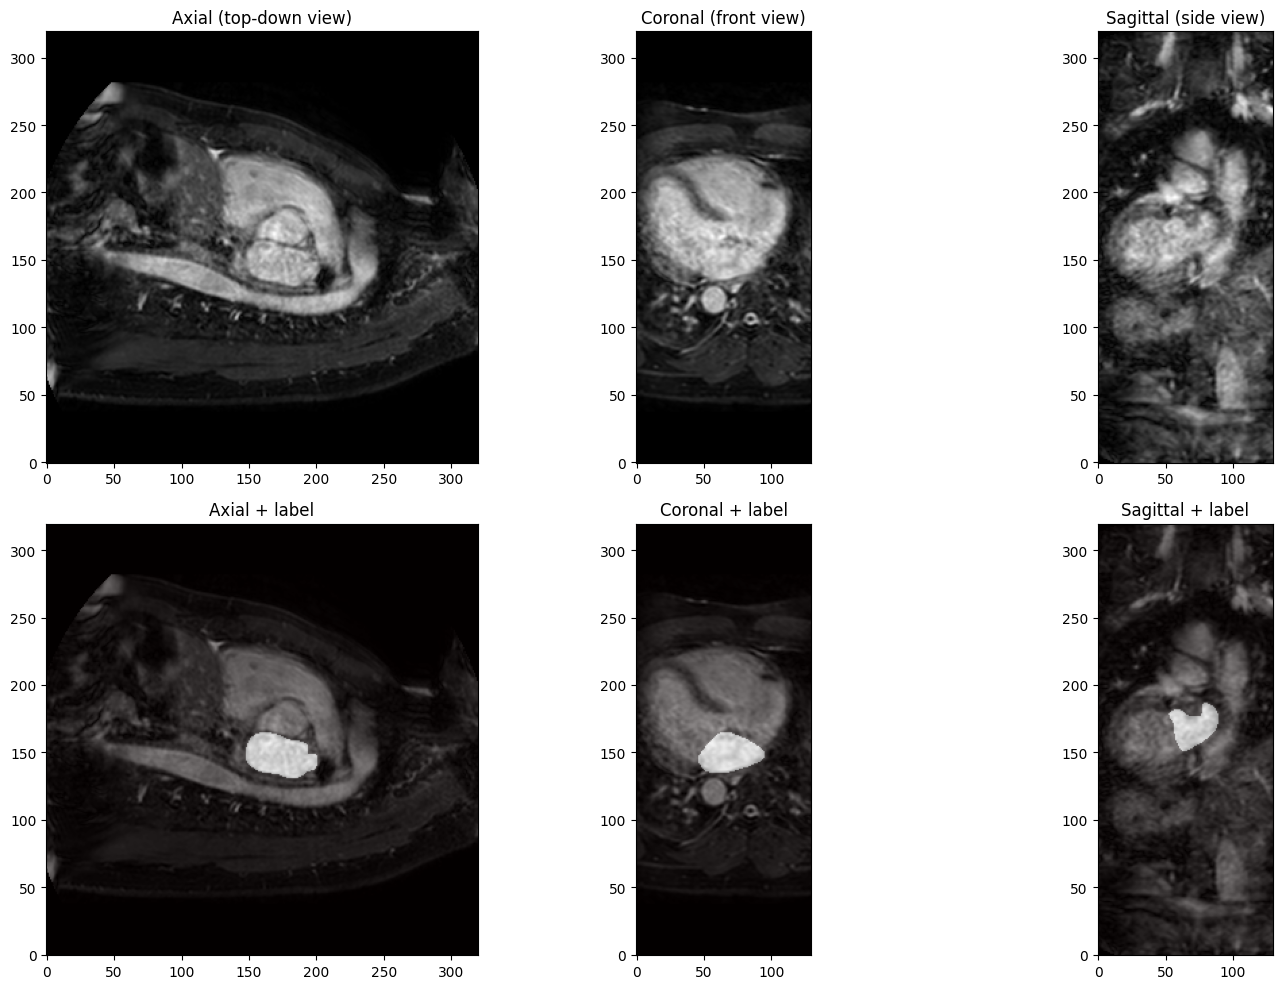

In [14]:
import matplotlib.pyplot as plt

# middle slice indices
x_mid = img_data.shape[0] // 2  # 160
y_mid = img_data.shape[1] // 2  # 160
z_mid = img_data.shape[2] // 2  # 65

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# --- ROW 1: raw MRI ---
axes[0, 0].imshow(img_data[:, :, z_mid], cmap='gray', origin='lower')
axes[0, 0].set_title('Axial (top-down view)')

axes[0, 1].imshow(img_data[:, y_mid, :], cmap='gray', origin='lower')
axes[0, 1].set_title('Coronal (front view)')

axes[0, 2].imshow(img_data[x_mid, :, :], cmap='gray', origin='lower')
axes[0, 2].set_title('Sagittal (side view)')

# --- ROW 2: MRI + label overlay ---
axes[1, 0].imshow(img_data[:, :, z_mid], cmap='gray', origin='lower')
axes[1, 0].imshow(label_data[:, :, z_mid], cmap='hot', alpha=0.4, origin='lower')
axes[1, 0].set_title('Axial + label')

axes[1, 1].imshow(img_data[:, y_mid, :], cmap='gray', origin='lower')
axes[1, 1].imshow(label_data[:, y_mid, :], cmap='hot', alpha=0.4, origin='lower')
axes[1, 1].set_title('Coronal + label')

axes[1, 2].imshow(img_data[x_mid, :, :], cmap='gray', origin='lower')
axes[1, 2].imshow(label_data[x_mid, :, :], cmap='hot', alpha=0.4, origin='lower')
axes[1, 2].set_title('Sagittal + label')

plt.tight_layout()
plt.show()

# Phase2 : Transform

In [15]:
# TASK: Import everything needed for Phase 2 transforms
# WHY: MONAI transform classes handle all preprocessing steps

from monai.transforms import (
    Compose,
    LoadImaged,
    EnsureChannelFirstd,
    Spacingd,
    Orientationd,
    ScaleIntensityRangePercentilesd,
    CropForegroundd,
    RandCropByPosNegLabeld,
    RandAffined,
    RandGaussianNoised,
    RandFlipd,
)
from monai.data import DataLoader, Dataset, CacheDataset

In [16]:
# TASK: Build data_dicts — list of {"image": path, "label": path} for all 20 volumes
# WHY: MONAI dictionary transforms expect this exact format


data_dir = Path("/content/drive/MyDrive/Cardiac-Segmentation/data/Task02_Heart")

data_dicts = [
    {"image": data_dir / "imagesTr" / img_name,
     "label": data_dir / "labelsTr" / lbl_name}
    for img_name, lbl_name in zip(images, labels)
]

print(f"Total samples: {len(data_dicts)}")
print(f"First entry: {data_dicts[0]}")

Total samples: 20
First entry: {'image': PosixPath('/content/drive/MyDrive/Cardiac-Segmentation/data/Task02_Heart/imagesTr/la_007.nii.gz'), 'label': PosixPath('/content/drive/MyDrive/Cardiac-Segmentation/data/Task02_Heart/labelsTr/la_007.nii.gz')}


In [17]:
# TASK: Split data_dicts into train and val sets
# WHY: Need separate sets — train for learning, val for honest evaluation


import random
random.seed(42)
random.shuffle(data_dicts)

train_files = data_dicts[:16]
val_files = data_dicts[16:]

print(f"Train:{len(train_files)}, Val:{len(val_files)}")

Train:16, Val:4


In [18]:
# TASK: Build the shared transform chain (applied to both train and val)
# WHY: These make data consistent and model-ready


shared_transforms = Compose([
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image", "label"]),
    Spacingd(
        keys=["image", "label"],
        pixdim=(1.5, 1.5, 1.5),
        mode=("bilinear", "nearest")  # why different modes? think about it
    ),
    Orientationd(keys=["image", "label"], axcodes="RAS"),
    CropForegroundd(keys=["image", "label"], source_key="image"),
    ScaleIntensityRangePercentilesd(
        keys=["image"],
        lower=0.5,
        upper=99.5,
        b_min=0.0,
        b_max=1.0,
        clip=True
    ),
])

/usr/local/lib/python3.12/dist-packages/monai/utils/deprecate_utils.py:321: FutureWarning: monai.transforms.spatial.dictionary Orientationd.__init__:labels: Current default value of argument `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` was changed in version None from `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` to `labels=None`. Default value changed to None meaning that the transform now uses the 'space' of a meta-tensor, if applicable, to determine appropriate axis labels.
  warn_deprecated(argname, msg, warning_category)


In [19]:
# TASK: Build train-specific transforms (augmentation + patch sampling)
# WHY: Artificially expand 16 volumes, prevent overfitting


train_transforms = Compose([
    shared_transforms,
    RandAffined(
        keys=["image", "label"],
        mode=("bilinear", "nearest"),
        prob=0.5,
        rotate_range=(0.35, 0.35, 0.35),
        scale_range=(0.1, 0.1, 0.1),
    ),
    RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=0),
    RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=1),
    RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=2),
    RandGaussianNoised(keys=["image"], prob=0.2, mean=0.0, std=0.1),
    RandCropByPosNegLabeld(
        keys=["image", "label"],
        label_key="label",
        spatial_size=(128, 128, 80),
        pos=1,
        neg=1,
        num_samples=2,
    ),
])

val_transforms = Compose([
    shared_transforms,
])

In [20]:
# TASK: Create Dataset and DataLoader for train and val
# WHY: Dataset applies transforms lazily, DataLoader batches and shuffles


from monai.data import pad_list_data_collate
train_ds = CacheDataset(
    data=train_files,
    transform=train_transforms,
    cache_rate=1.0,
)

val_ds = CacheDataset(
    data=val_files,
    transform=val_transforms,
    cache_rate=1.0,
)

train_loader = DataLoader(train_ds, batch_size=2, shuffle=True, collate_fn=pad_list_data_collate,)
val_loader = DataLoader(val_ds, batch_size=2, shuffle=False, collate_fn=pad_list_data_collate,)

Loading dataset: 100%|██████████| 4/4 [00:00<00:00, 26504.29it/s]


In [21]:
# TASK: Pull one batch and inspect its shape
# WHY: This tells us if patches were actually extracted and transformed correctly

batch = next(iter(train_loader))
print(batch["image"].shape)
print(batch["label"].shape)
print(batch["image"].min(), batch["image"].max())
print(batch["label"].unique())

torch.Size([4, 1, 128, 128, 80])
torch.Size([4, 1, 128, 128, 80])
metatensor(0.) metatensor(1.)
metatensor([0., 1.])


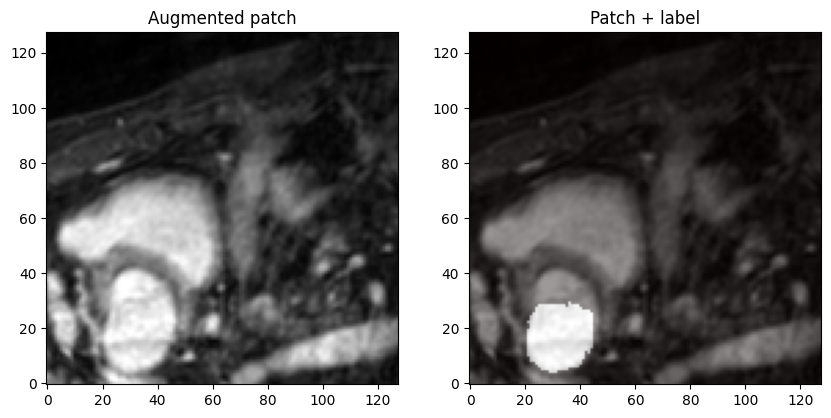

In [22]:
img_patch = batch["image"][0, 0]   # first patch, remove channel dim
lbl_patch = batch["label"][0, 0]

z_mid = img_patch.shape[2] // 2

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(img_patch[:, :, z_mid], cmap='gray', origin='lower')
axes[0].set_title('Augmented patch')

axes[1].imshow(img_patch[:, :, z_mid], cmap='gray', origin='lower')
axes[1].imshow(lbl_patch[:, :, z_mid], cmap='hot', alpha=0.4, origin='lower')
axes[1].set_title('Patch + label')

plt.show()

PHASE 3: SegResnet

In [23]:
# TASK: Check if CUDA is available and set device accordingly
# WHY: Model and data must be on the same device (GPU) for training
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


print(device)

cuda


In [24]:
from monai.networks.nets import SegResNet

model = SegResNet(
    spatial_dims=3,
    in_channels=1,
    out_channels=2,
    init_filters=32,
    blocks_down=(1, 2, 2, 4),
    blocks_up=(1, 1, 1),
    dropout_prob=0.2,
).to(device)

In [25]:
# Forward Pass Sanity Check

model.eval()
with torch.no_grad():
    test_batch = next(iter(train_loader))
    test_input = test_batch["image"].to(device)
    test_output = model(test_input)

print(f"Input shape: {test_input.shape}")
print(f"Output shape: {test_output.shape}")

Input shape: torch.Size([4, 1, 128, 128, 80])
Output shape: torch.Size([4, 2, 128, 128, 80])


In [26]:
from monai.losses import DiceCELoss

loss_function = DiceCELoss(
    to_onehot_y=True,
    softmax=True,
)

In [27]:
from monai.metrics import DiceMetric

dice_metric = DiceMetric(
    include_background=False,
    reduction="mean",
)

In [28]:
import torch

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-5,
)

In [30]:
from monai.data import decollate_batch
# TASK: Training loop with periodic validation and checkpointing
# WHY: Train the model, track real generalisation via val Dice, save best weights

from monai.inferers import sliding_window_inference
from monai.transforms import AsDiscrete
import os

max_epochs = 100
val_interval = 5          # run validation every 5 epochs
best_metric = -1
best_metric_epoch = -1

epoch_loss_values = []
metric_values = []

# Helper to convert raw model output / labels into discrete one-hot format for DiceMetric
post_pred = AsDiscrete(argmax=True, to_onehot=2)
post_label = AsDiscrete(to_onehot=2)

for epoch in range(max_epochs):
    print(f"Epoch {epoch+1}/{max_epochs}")
    model.train()
    epoch_loss = 0
    step = 0

    for batch in train_loader:
        step += 1
        inputs = batch["image"].to(device)
        labels = batch["label"].to(device)

        # TASK: standard training step
        # WHY: zero grads, forward, compute loss, backward, optimizer step
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = loss_function(outputs,labels)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    epoch_loss /= step
    epoch_loss_values.append(epoch_loss)
    print(f"  Train loss: {epoch_loss:.4f}")

    if (epoch + 1) % val_interval == 0:
        model.eval()
        with torch.no_grad():
            for val_batch in val_loader:
                val_inputs = val_batch["image"].to(device)
                val_labels = val_batch["label"].to(device)

                # TASK: run sliding window inference instead of direct forward pass
                # WHY: val volumes are full-size, model expects patch-sized input

                val_outputs = sliding_window_inference(
                    val_inputs, (128, 128, 80), 4, model
                )

                val_outputs_list = [post_pred(i) for i in decollate_batch(val_outputs)]
                val_labels_list = [post_label(i) for i in decollate_batch(val_labels)]

                dice_metric(y_pred=val_outputs_list, y=val_labels_list)

            metric = dice_metric.aggregate().item()
            dice_metric.reset()
            metric_values.append(metric)
            print(f"  Val Dice: {metric:.4f}")

            if metric > best_metric:
                best_metric = metric
                best_metric_epoch = epoch + 1
                torch.save(model.state_dict(), "best_metric_model.pth")
                print(f"  New best model saved! Dice: {best_metric:.4f}")

print(f"Training complete. Best Dice: {best_metric:.4f} at epoch {best_metric_epoch}")

Epoch 1/100
  Train loss: 0.6328
Epoch 2/100
  Train loss: 0.6228
Epoch 3/100
  Train loss: 0.6161
Epoch 4/100
  Train loss: 0.6071
Epoch 5/100
  Train loss: 0.6001


/usr/local/lib/python3.12/dist-packages/monai/inferers/utils.py:226: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:347.)
  win_data = torch.cat([inputs[win_slice] for win_slice in unravel_slice]).to(sw_device)
/usr/local/lib/python3.12/dist-packages/monai/inferers/utils.py:370: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:347.)
  out

  Val Dice: 0.3406
  New best model saved! Dice: 0.3406
Epoch 6/100
  Train loss: 0.5948
Epoch 7/100
  Train loss: 0.5832
Epoch 8/100
  Train loss: 0.5705
Epoch 9/100
  Train loss: 0.5545
Epoch 10/100
  Train loss: 0.5487
  Val Dice: 0.4111
  New best model saved! Dice: 0.4111
Epoch 11/100
  Train loss: 0.5402
Epoch 12/100
  Train loss: 0.5387
Epoch 13/100
  Train loss: 0.5366
Epoch 14/100
  Train loss: 0.5507
Epoch 15/100
  Train loss: 0.5246
  Val Dice: 0.4961
  New best model saved! Dice: 0.4961
Epoch 16/100
  Train loss: 0.5122
Epoch 17/100
  Train loss: 0.5078
Epoch 18/100
  Train loss: 0.4999
Epoch 19/100
  Train loss: 0.4886
Epoch 20/100
  Train loss: 0.4696
  Val Dice: 0.4737
Epoch 21/100
  Train loss: 0.4891
Epoch 22/100
  Train loss: 0.4835
Epoch 23/100
  Train loss: 0.4712
Epoch 24/100
  Train loss: 0.4501
Epoch 25/100
  Train loss: 0.4466
  Val Dice: 0.6017
  New best model saved! Dice: 0.6017
Epoch 26/100
  Train loss: 0.4555
Epoch 27/100
  Train loss: 0.4357
Epoch 28/100


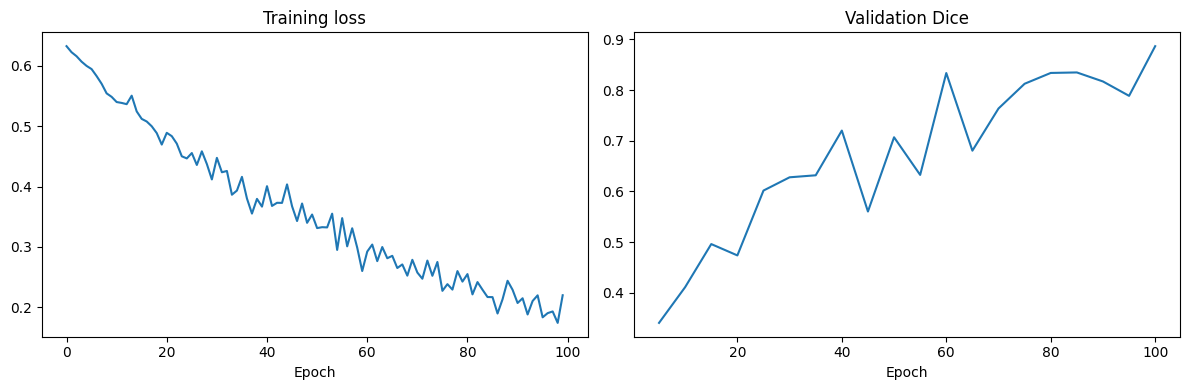

In [32]:
# TASK: Plot training loss and validation Dice over epochs
# WHY: Visual evidence of training behaviour for README/portfolio

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epoch_loss_values)
axes[0].set_title("Training loss")
axes[0].set_xlabel("Epoch")

val_epochs = [val_interval * (i + 1) for i in range(len(metric_values))]
axes[1].plot(val_epochs, metric_values)
axes[1].set_title("Validation Dice")
axes[1].set_xlabel("Epoch")

plt.tight_layout()
plt.show()

In [33]:
# TASK: Copy the saved model checkpoint to Google Drive



import shutil
from pathlib import Path

# Make a dedicated folder for model weights in your repo's Drive location
weights_dir = Path("/content/drive/MyDrive/Cardiac-Segmentation/models")
weights_dir.mkdir(parents=True, exist_ok=True)

shutil.copy("best_metric_model.pth", weights_dir / "best_metric_model.pth")

print(f"Saved to: {weights_dir / 'best_metric_model.pth'}")

Saved to: /content/drive/MyDrive/Cardiac-Segmentation/models/best_metric_model.pth


In [34]:
print(list(weights_dir.iterdir()))

[PosixPath('/content/drive/MyDrive/Cardiac-Segmentation/models/best_metric_model.pth')]


In [38]:
# TASK: Create a batch_size=1 loader specifically for per-patient analysis
# WHY: batch_size=2 was pairing patients together, hiding individual variation

val_loader_single = DataLoader(val_ds, batch_size=1, shuffle=False, collate_fn=pad_list_data_collate)

per_patient_dice = []

with torch.no_grad():
    for val_batch in val_loader_single:
        val_inputs = val_batch["image"].to(device)
        val_labels = val_batch["label"].to(device)

        val_outputs = sliding_window_inference(
            val_inputs, (128, 128, 80), 4, model
        )

        val_outputs_list = [post_pred(i) for i in decollate_batch(val_outputs)]
        val_labels_list = [post_label(i) for i in decollate_batch(val_labels)]

        dice_metric(y_pred=val_outputs_list, y=val_labels_list)
        patient_dice = dice_metric.aggregate().item()
        per_patient_dice.append(patient_dice)
        dice_metric.reset()

print(per_patient_dice)

[0.9101069569587708, 0.8733715415000916, 0.8847540616989136, 0.8897046446800232]


# Phase 4: Clinical Analysis

In [39]:
# TASK: Add HD95 metric alongside DiceMetric
# WHY: Boundary precision matters clinically, Dice alone doesn't capture it

from monai.metrics import HausdorffDistanceMetric

hd95_metric = HausdorffDistanceMetric(
    include_background=False,
    percentile=95,
    reduction="mean",
)

In [42]:
per_patient_dice = []
per_patient_hd95 = []

with torch.no_grad():
    for val_batch in val_loader_single:
        val_inputs = val_batch["image"].to(device)
        val_labels = val_batch["label"].to(device)

        val_outputs = sliding_window_inference(
            val_inputs, (128, 128, 80), 4, model
        )

        val_outputs_list = [post_pred(i) for i in decollate_batch(val_outputs)]
        val_labels_list = [post_label(i) for i in decollate_batch(val_labels)]

        dice_metric(y_pred=val_outputs_list, y=val_labels_list)

        # move to CPU specifically for HD95 to avoid the cuCIM/cupy compilation issue
        val_outputs_cpu = [o.cpu() for o in val_outputs_list]
        val_labels_cpu = [l.cpu() for l in val_labels_list]
        hd95_metric(y_pred=val_outputs_cpu, y=val_labels_cpu)

        per_patient_dice.append(dice_metric.aggregate().item())
        per_patient_hd95.append(hd95_metric.aggregate().item())

        dice_metric.reset()
        hd95_metric.reset()

print("Dice:", per_patient_dice)
print("HD95:", per_patient_hd95)

Dice: [0.9101069569587708, 0.8733715415000916, 0.8847540616989136, 0.8897046446800232]
HD95: [3.7416574954986572, 36.400550842285156, 8.803361892700195, 4.358899116516113]


In [43]:
# TASK: Run inference on val patient 2 specifically, visualise the raw prediction
# WHY: Confirm whether a disconnected false-positive blob explains the HD95 spike

model.eval()
with torch.no_grad():
    for idx, val_batch in enumerate(val_loader):
        if idx != 1:  # skip to patient 2
            continue
        val_inputs = val_batch["image"].to(device)
        val_labels = val_batch["label"].to(device)
        val_outputs = sliding_window_inference(val_inputs, (128, 128, 80), 4, model)
        pred = torch.argmax(val_outputs, dim=1)[0].cpu().numpy()  # discrete prediction
        break

print(pred.shape)
print(f"Total predicted atrium voxels: {(pred == 1).sum()}")

(204, 267, 119)
Total predicted atrium voxels: 30446


In [44]:
# TASK: Count disconnected components in the prediction
# WHY: Confirm whether a stray blob is causing the HD95 spike


from scipy import ndimage

labeled_array, num_components = ndimage.label(pred)
print(f"Number of disconnected components: {num_components}")

# size of each component, in voxels
component_sizes = ndimage.sum(pred, labeled_array, range(1, num_components + 1))
print(f"Component sizes: {sorted(component_sizes, reverse=True)}")

Number of disconnected components: 1
Component sizes: [np.float64(30446.0)]


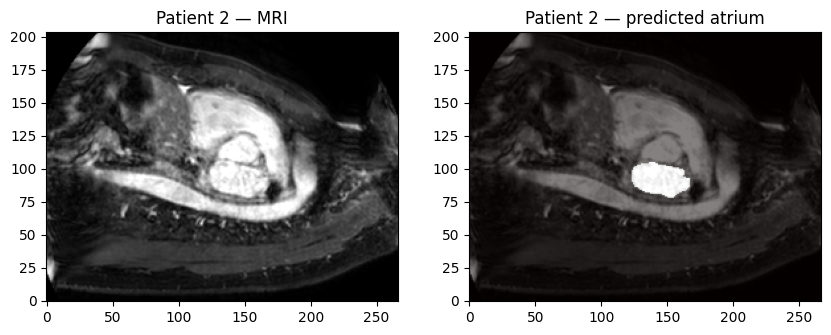

In [45]:
import matplotlib.pyplot as plt

z_mid = pred.shape[2] // 2

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(val_inputs[0, 0, :, :, z_mid].cpu(), cmap='gray', origin='lower')
axes[0].set_title('Patient 2 — MRI')

axes[1].imshow(val_inputs[0, 0, :, :, z_mid].cpu(), cmap='gray', origin='lower')
axes[1].imshow(pred[:, :, z_mid], cmap='hot', alpha=0.5, origin='lower')
axes[1].set_title('Patient 2 — predicted atrium')

plt.show()

In [46]:
# TASK: Compare Z-extent of prediction vs ground truth for patient 2
# WHY: Check if the model is missing part of the atrium specifically along Z


label_np = val_labels[0, 0].cpu().numpy()

pred_z_slices = (pred.sum(axis=(0,1)) > 0)
label_z_slices = (label_np.sum(axis=(0,1)) > 0)

pred_z_range = (pred_z_slices.argmax(), len(pred_z_slices) - pred_z_slices[::-1].argmax())
label_z_range = (label_z_slices.argmax(), len(label_z_slices) - label_z_slices[::-1].argmax())

print(f"Prediction Z range: {pred_z_range}")
print(f"Ground truth Z range: {label_z_range}")

Prediction Z range: (np.int64(38), np.int64(100))
Ground truth Z range: (np.int64(37), np.int64(106))


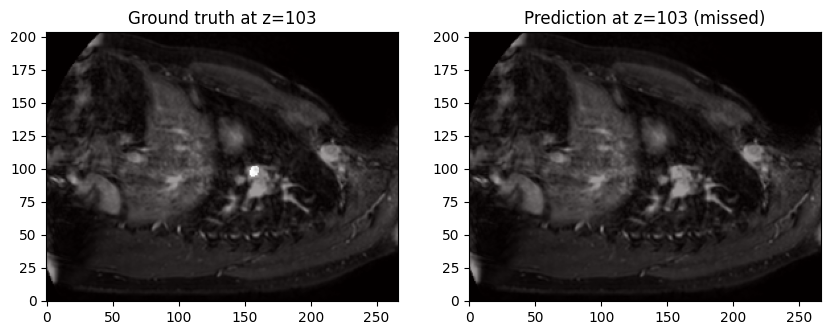

In [47]:
# TASK: Visualise the exact Z-slice where prediction stops but ground truth continues
# WHY: Directly see the truncation, not just infer it from numbers

z_check = 103  # within ground truth range, outside prediction range

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(val_inputs[0, 0, :, :, z_check].cpu(), cmap='gray', origin='lower')
axes[0].imshow(label_np[:, :, z_check], cmap='hot', alpha=0.4, origin='lower')
axes[0].set_title(f'Ground truth at z={z_check}')

axes[1].imshow(val_inputs[0, 0, :, :, z_check].cpu(), cmap='gray', origin='lower')
axes[1].imshow(pred[:, :, z_check], cmap='hot', alpha=0.4, origin='lower')
axes[1].set_title(f'Prediction at z={z_check} (missed)')

plt.show()

In [48]:
# TASK: Build a clean results summary


import pandas as pd

results = pd.DataFrame({
    "Patient": [1, 2, 3, 4],
    "Dice": per_patient_dice,
    "HD95 (mm)": per_patient_hd95,
})

results.loc["Mean"] = ["—", results["Dice"].mean(), results["HD95 (mm)"].mean()]
print(results.to_string(index=False))

Patient     Dice  HD95 (mm)
      1 0.910107   3.741657
      2 0.873372  36.400551
      3 0.884754   8.803362
      4 0.889705   4.358899
      — 0.889484  13.326117


Phase 5: Deployment

In [3]:
%%writefile /content/Cardiac-Segmentation/src/transforms.py
from monai.transforms import (
    Compose,
    LoadImaged,
    EnsureChannelFirstd,
    Spacingd,
    Orientationd,
    CropForegroundd,
    ScaleIntensityRangePercentilesd,
)


def get_inference_transforms():
    return Compose([
        LoadImaged(keys=["image"]),
        EnsureChannelFirstd(keys=["image"]),
        Spacingd(keys=["image"], pixdim=(1.5, 1.5, 1.5), mode="bilinear"),
        Orientationd(keys=["image"], axcodes="RAS"),
        CropForegroundd(keys=["image"], source_key="image"),
        ScaleIntensityRangePercentilesd(
            keys=["image"], lower=0.5, upper=99.5, b_min=0.0, b_max=1.0, clip=True
        ),
    ])

Writing /content/Cardiac-Segmentation/src/transforms.py


In [6]:
%%writefile /content/Cardiac-Segmentation/src/model.py
import torch
from monai.networks.nets import SegResNet


def build_model(device=None):
    """
    Returns the SegResNet architecture used for left atrium segmentation.
    Weights must be loaded separately via model.load_state_dict(...).
    """
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model = SegResNet(
        spatial_dims=3,
        in_channels=1,
        out_channels=2,
        init_filters=32,
        blocks_down=(1, 2, 2, 4),
        blocks_up=(1, 1, 1),
        dropout_prob=0.2,
    ).to(device)

    return model

Writing /content/Cardiac-Segmentation/src/model.py


In [5]:
import getpass
token = getpass.getpass("Paste token: ")

# Save current notebook to Drive first, THEN push
import shutil

shutil.copy("/content/drive/MyDrive/Colab Notebooks/Medical Segmentation Decathlon.ipynb",
            "/content/Cardiac-Segmentation/notebooks/cardiac_segmentation.ipynb")
!git pull --no-edit https://{token}@github.com/shubhamkovhal01/Cardiac-Segmentation.git
!git add .
!git commit -m "feat: extract inference transform pipeline to src/"
!git push https://{token}@github.com/shubhamkovhal01/Cardiac-Segmentation.git

Paste token: ··········
From https://github.com/shubhamkovhal01/Cardiac-Segmentation
 * branch            HEAD       -> FETCH_HEAD
Already up to date.
[main fa4987f] feat: extract inference transform pipeline to src/
 2 files changed, 23 insertions(+), 1 deletion(-)
 rewrite notebooks/cardiac_segmentation.ipynb (84%)
 create mode 100644 src/transforms.py
Enumerating objects: 10, done.
Counting objects: 100% (10/10), done.
Delta compression using up to 8 threads
Compressing objects: 100% (6/6), done.
Writing objects: 100% (6/6), 1.83 KiB | 93.00 KiB/s, done.
Total 6 (delta 3), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (3/3), completed with 3 local objects.
To https://github.com/shubhamkovhal01/Cardiac-Segmentation.git
   76b6ef8..fa4987f  main -> main
